# ============================================
# AGRI-WATCH Sénégal
# Notebook 08 - Système d'Alertes Précoces
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

In [1]:
# Objectif :
# Transformer les prédictions ML du
# Notebook 07 en alertes opérationnelles
# pour les décideurs du gouvernement
# sénégalais et ses partenaires
# FAO, PAM, FIDA.
#
# Contenu :
# 1. Classification niveaux d'alerte
# 2. Validation sur 2021-2022
# 3. Application temps réel 2024
# 4. Carte nationale de risque
# 5. Bulletin automatique PDF
#
# Sources :
#   FAO/PAM (2023). IPC — Integrated
#   Food Security Phase Classification.
#   ipcinfo.org
#
#   FAO/GIEWS (2024). Early Warning
#   Early Action. Rome.
#   fao.org/giews
# ============================================

import sys
import warnings
warnings.filterwarnings('ignore')

if "C:/AGRI-WATCH" not in sys.path:
    sys.path.append("C:/AGRI-WATCH")

for module in list(sys.modules.keys()):
    if module.startswith('src'):
        del sys.modules[module]

print("Setup termine avec succes.")

Setup termine avec succes.


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import joblib
from datetime import datetime

from src.config import (
    SHAPEFILE_DEPARTEMENTS,
    SHAPEFILE_REGIONS,
    COL_NOM_DEPARTEMENT,
    RANDOM_STATE,
    creer_dossiers
)
from src.logger import get_logger

creer_dossiers()
logger = get_logger("systeme_alertes")
logger.info("Notebook 08 - Systeme alertes - Demarrage")
print("Imports termines avec succes.")

Structure des dossiers AGRI-WATCH verifiee avec succes.
Racine du projet : C:\AGRI-WATCH
[2026-06-01 00:27:07] [INFO] [agriwatch.systeme_alertes] Notebook 08 - Systeme alertes - Demarrage
Imports termines avec succes.


In [4]:
# ============================================
# Chargement modèles sauvegardés
# ============================================

racine       = Path("C:/AGRI-WATCH")
departements = gpd.read_file(SHAPEFILE_DEPARTEMENTS)
regions      = gpd.read_file(SHAPEFILE_REGIONS)

# ── Chargement modèles ────────────────────────────────────────
dossier_modeles = racine / "models"

model_arachide = joblib.load(
    dossier_modeles / "rf_arachide.joblib"
)
model_mil = joblib.load(
    dossier_modeles / "xgb_mil.joblib"
)
features       = joblib.load(
    dossier_modeles / "features.joblib"
)
tendances      = joblib.load(
    dossier_modeles / "tendances.joblib"
)
normales       = joblib.load(
    dossier_modeles / "normales_historiques.joblib"
)

# ── Chargement dataset complet ────────────────────────────────
dataset = pd.read_csv(
    racine / "data/processed/"
    "dataset_ml_complet_2000_2022.csv",
    encoding = "utf-8-sig"
)

print("=" * 65)
print("CHARGEMENT MODELES ET DONNEES")
print("=" * 65)
print(f"Modele arachide  : Random Forest")
print(f"Modele mil       : XGBoost")
print(f"Features arachide: {len(features['rf_arachide'])} variables")
print(f"Features mil     : {len(features['xgb_mil'])} variables")
print(f"Dataset          : {len(dataset):,} lignes")
print(f"Normales         : {len(normales['Arachide'])} depts")

logger.info("Modeles et donnees charges.")
print("=" * 65)

CHARGEMENT MODELES ET DONNEES
Modele arachide  : Random Forest
Modele mil       : XGBoost
Features arachide: 11 variables
Features mil     : 15 variables
Dataset          : 1,617 lignes
Normales         : 42 depts
[2026-06-01 00:29:07] [INFO] [agriwatch.systeme_alertes] Modeles et donnees charges.


In [5]:
# ============================================
# Seuils d'alerte
# ============================================
# Classification basée sur le déficit
# de rendement par rapport à la normale
# historique du département
#
# Sources :
#   FAO/PAM (2023). IPC Phase Classification.
#   ipcinfo.org
#
#   FAO/GIEWS ASIS (2017).
#   Agricultural Stress Index System.
#   fao.org/giews/earthobservation
# ============================================

# Seuils de déficit par rapport à la normale
SEUILS_ALERTE = {
    "Normal"         : (0,    float("inf")),  # > 0%
    "Surveillance"   : (-0.10, 0),            # -10% à 0%
    "Alerte moderee" : (-0.25, -0.10),        # -25% à -10%
    "Alerte elevee"  : (-0.40, -0.25),        # -40% à -25%
    "Alerte critique": (float("-inf"), -0.40) # < -40%
}

COULEURS_ALERTE = {
    "Normal"         : "#4CAF50",  # Vert
    "Surveillance"   : "#FFEB3B",  # Jaune
    "Alerte moderee" : "#FF9800",  # Orange
    "Alerte elevee"  : "#F44336",  # Rouge
    "Alerte critique": "#7B1FA2",  # Violet
}

CODES_ALERTE = {
    "Normal"         : 0,
    "Surveillance"   : 1,
    "Alerte moderee" : 2,
    "Alerte elevee"  : 3,
    "Alerte critique": 4,
}

def classifier_alerte(deficit_pct):
    """
    Classe le niveau d'alerte selon
    le déficit de rendement prévu.

    Sources :
        FAO/PAM (2023). IPC.
        FAO/GIEWS ASIS (2017).

    Paramètre :
        deficit_pct : déficit en proportion
                      (ex: -0.28 = -28%)

    Retourne :
        str : niveau d'alerte
    """
    for niveau, (seuil_bas, seuil_haut) in \
            SEUILS_ALERTE.items():
        if seuil_bas <= deficit_pct < seuil_haut:
            return niveau
    return "Alerte critique"

print("=" * 65)
print("SEUILS D'ALERTE AGRI-WATCH")
print("Source : FAO/PAM IPC (2023)")
print("=" * 65)
print(f"\n{'Niveau':<20} {'Seuil':>15} {'Couleur':>10}")
print("-" * 50)
for niveau, (bas, haut) in SEUILS_ALERTE.items():
    if haut == float("inf"):
        seuil_str = "> 0%"
    elif bas == float("-inf"):
        seuil_str = "< -40%"
    else:
        seuil_str = f"{bas*100:.0f}% à {haut*100:.0f}%"
    print(
        f"{niveau:<20} {seuil_str:>15} "
        f"{COULEURS_ALERTE[niveau]:>10}"
    )

logger.info("Seuils d'alerte definis.")
print("=" * 65)

SEUILS D'ALERTE AGRI-WATCH
Source : FAO/PAM IPC (2023)

Niveau                         Seuil    Couleur
--------------------------------------------------
Normal                          > 0%    #4CAF50
Surveillance               -10% à 0%    #FFEB3B
Alerte moderee           -25% à -10%    #FF9800
Alerte elevee            -40% à -25%    #F44336
Alerte critique               < -40%    #7B1FA2
[2026-06-01 00:30:05] [INFO] [agriwatch.systeme_alertes] Seuils d'alerte definis.


In [7]:
# ============================================
# Fonction prédiction + alerte
# ============================================

def predire_rendements_alertes(
    dataset_input: pd.DataFrame,
    annee: int,
    model_arachide,
    model_mil,
    features: dict,
    tendances: dict,
    normales: dict
) -> pd.DataFrame:
    """
    Prédit les rendements et classe les
    niveaux d'alerte pour tous les
    départements d'une année donnée.

    Paramètres :
        dataset_input  : DataFrame avec features
        annee          : Année de prédiction
        model_arachide : Modèle RF arachide
        model_mil      : Modèle XGBoost mil
        features       : Features par culture
        tendances      : Tendances par dept
        normales       : Normales historiques

    Retourne :
        DataFrame : prédictions + alertes
    """
    resultats = []

    for culture, model in [
        ("Arachide", model_arachide),
        ("Mil",      model_mil)
    ]:
        feat = features[
            "rf_arachide"
            if culture == "Arachide"
            else "xgb_mil"
        ]
        tend = tendances[
            "rf_arachide"
            if culture == "Arachide"
            else "xgb_mil"
        ]
        norm = normales[culture].set_index(
            "departement"
        )

        df_c = dataset_input[
            dataset_input["culture"] == culture
        ].copy()

        if len(df_c) == 0:
            continue

        # Vérification features disponibles
        feat_dispo = [
            f for f in feat
            if f in df_c.columns
        ]

        if len(feat_dispo) < len(feat):
            manquants = set(feat) - set(feat_dispo)
            logger.warning(
                f"Features manquantes {culture} : "
                f"{manquants}"
            )

        X = df_c[feat_dispo]

        # Prédiction désaisonnalisée
        y_pred_dt = model.predict(X)

        # Réapplication tendance
        for i, (_, row) in enumerate(
            df_c.iterrows()
        ):
            dept  = row["departement"]
            key   = f"{culture}_{dept}"
            trend = 0

            if key in tend:
                t     = tend[key]
                trend = (
                    t["slope"] * annee
                    + t["intercept"]
                )

            rend_predit = y_pred_dt[i] + trend
            rend_predit = max(0, rend_predit)

            # Normale historique
            if dept in norm.index:
                rend_normal = norm.loc[dept, "moy"]
            else:
                rend_normal = df_c[
                    "rendement"
                ].mean()

            # Déficit
            deficit_pct = (
                (rend_predit - rend_normal)
                / rend_normal
            )

            # Classification alerte
            niveau = classifier_alerte(deficit_pct)

            resultats.append({
                "departement"  : dept,
                "culture"      : culture,
                "annee"        : annee,
                "rend_predit"  : round(rend_predit, 0),
                "rend_normal"  : round(rend_normal, 0),
                "deficit_pct"  : round(deficit_pct * 100, 1),
                "niveau_alerte": niveau,
                "code_alerte"  : CODES_ALERTE[niveau],
                "couleur"      : COULEURS_ALERTE[niveau]
            })

    return pd.DataFrame(resultats)


print("Fonction predire_rendements_alertes definie")
logger.info("Fonction prediction alertes definie.")

Fonction predire_rendements_alertes definie
[2026-06-01 00:34:00] [INFO] [agriwatch.systeme_alertes] Fonction prediction alertes definie.


In [11]:
# ============================================
# Calcul lags pour prédiction
# ============================================

def ajouter_lags(
    dataset_complet: pd.DataFrame,
    annee_cible: int
) -> pd.DataFrame:
    """
    Calcule les variables lags pour
    une année cible en utilisant
    les données de l'année précédente.

    Paramètre :
        dataset_complet : Dataset complet
        annee_cible     : Année à prédire

    Retourne :
        DataFrame avec lags calculés
    """
    # Données année cible
    df_cible = dataset_complet[
        dataset_complet["annee"] == annee_cible
    ].copy()

    # Données année précédente
    df_lag = dataset_complet[
        dataset_complet["annee"] == annee_cible - 1
    ][["departement", "culture",
       "rendement", "pluie_totale",
       "ndvi_sept", "spi"]].copy()

    df_lag = df_lag.rename(columns={
        "rendement"   : "rendement_lag1",
        "pluie_totale": "pluie_lag1",
        "ndvi_sept"   : "ndvi_sept_lag1",
        "spi"         : "spi_lag1"
    })

    # Fusion
    df_result = df_cible.merge(
        df_lag,
        on  = ["departement", "culture"],
        how = "left"
    )

    return df_result

print("Fonction ajouter_lags definie")

Fonction ajouter_lags definie


In [12]:
# ============================================
# Validation alertes 2021-2022
# ============================================

print("=" * 65)
print("VALIDATION SYSTEME D'ALERTES 2021-2022")
print("=" * 65)

alertes_validation = []

for annee in [2021, 2022]:

    # Ajout des lags avant prédiction
    df_annee = ajouter_lags(dataset, annee)

    alertes = predire_rendements_alertes(
        dataset_input  = df_annee,
        annee          = annee,
        model_arachide = model_arachide,
        model_mil      = model_mil,
        features       = features,
        tendances      = tendances,
        normales       = normales
    )
    alertes_validation.append(alertes)

df_alertes_val = pd.concat(
    alertes_validation, ignore_index=True
)

# ── Résultats ─────────────────────────────────────────────────
for annee in [2021, 2022]:
    print(f"\nSaison {annee} :")
    df_an = df_alertes_val[
        df_alertes_val["annee"] == annee
    ]

    for culture in ["Arachide", "Mil"]:
        df_c = df_an[df_an["culture"] == culture]
        print(f"\n   {culture} :")
        print(
            f"   Rendement moyen prédit  : "
            f"{df_c['rend_predit'].mean():.0f} kg/ha"
        )
        print(
            f"   Rendement moyen normal  : "
            f"{df_c['rend_normal'].mean():.0f} kg/ha"
        )
        print(
            f"   Déficit moyen prédit    : "
            f"{df_c['deficit_pct'].mean():+.1f}%"
        )

        print(f"\n   Distribution alertes :")
        for niveau in SEUILS_ALERTE.keys():
            nb  = (df_c["niveau_alerte"] == niveau).sum()
            pct = nb / len(df_c) * 100
            if nb > 0:
                print(
                    f"   {niveau:<20} : "
                    f"{nb:>3} depts ({pct:.0f}%)"
                )

logger.info("Validation alertes 2021-2022 terminee.")
print("\n" + "=" * 65)

VALIDATION SYSTEME D'ALERTES 2021-2022

Saison 2021 :

   Arachide :
   Rendement moyen prédit  : 1064 kg/ha
   Rendement moyen normal  : 933 kg/ha
   Déficit moyen prédit    : +13.4%

   Distribution alertes :
   Normal               :  34 depts (81%)
   Surveillance         :   5 depts (12%)
   Alerte moderee       :   2 depts (5%)
   Alerte elevee        :   1 depts (2%)

   Mil :
   Rendement moyen prédit  : 878 kg/ha
   Rendement moyen normal  : 776 kg/ha
   Déficit moyen prédit    : +13.3%

   Distribution alertes :
   Normal               :  27 depts (71%)
   Surveillance         :   5 depts (13%)
   Alerte moderee       :   3 depts (8%)
   Alerte elevee        :   1 depts (3%)
   Alerte critique      :   2 depts (5%)

Saison 2022 :

   Arachide :
   Rendement moyen prédit  : 1215 kg/ha
   Rendement moyen normal  : 933 kg/ha
   Déficit moyen prédit    : +32.4%

   Distribution alertes :
   Normal               :  40 depts (95%)
   Surveillance         :   1 depts (2%)
   Alerte 

In [13]:
print("RESULTATS COMPLETS VALIDATION :")
for annee in [2021, 2022]:
    df_an = df_alertes_val[
        df_alertes_val["annee"] == annee
    ]
    print(f"\nSaison {annee} :")
    for culture in ["Arachide", "Mil"]:
        df_c = df_an[df_an["culture"] == culture]
        print(f"\n   {culture} :")
        print(f"   Rend prédit : {df_c['rend_predit'].mean():.0f} kg/ha")
        print(f"   Rend normal : {df_c['rend_normal'].mean():.0f} kg/ha")
        print(f"   Déficit     : {df_c['deficit_pct'].mean():+.1f}%")
        print(f"   Distribution :")
        for niveau in SEUILS_ALERTE.keys():
            nb  = (df_c["niveau_alerte"] == niveau).sum()
            pct = nb / len(df_c) * 100
            if nb > 0:
                print(f"   {niveau:<20} : {nb:>3} ({pct:.0f}%)")

RESULTATS COMPLETS VALIDATION :

Saison 2021 :

   Arachide :
   Rend prédit : 1064 kg/ha
   Rend normal : 933 kg/ha
   Déficit     : +13.4%
   Distribution :
   Normal               :  34 (81%)
   Surveillance         :   5 (12%)
   Alerte moderee       :   2 (5%)
   Alerte elevee        :   1 (2%)

   Mil :
   Rend prédit : 878 kg/ha
   Rend normal : 776 kg/ha
   Déficit     : +13.3%
   Distribution :
   Normal               :  27 (71%)
   Surveillance         :   5 (13%)
   Alerte moderee       :   3 (8%)
   Alerte elevee        :   1 (3%)
   Alerte critique      :   2 (5%)

Saison 2022 :

   Arachide :
   Rend prédit : 1215 kg/ha
   Rend normal : 933 kg/ha
   Déficit     : +32.4%
   Distribution :
   Normal               :  40 (95%)
   Surveillance         :   1 (2%)
   Alerte moderee       :   1 (2%)

   Mil :
   Rend prédit : 976 kg/ha
   Rend normal : 776 kg/ha
   Déficit     : +30.8%
   Distribution :
   Normal               :  32 (84%)
   Surveillance         :   4 (11%)
   Al

In [14]:
print("SAISON 2022 COMPLETE :")
df_2022 = df_alertes_val[df_alertes_val["annee"] == 2022]
for culture in ["Arachide", "Mil"]:
    df_c = df_2022[df_2022["culture"] == culture]
    print(f"\n{culture} :")
    print(f"   Rend prédit : {df_c['rend_predit'].mean():.0f} kg/ha")
    print(f"   Rend normal : {df_c['rend_normal'].mean():.0f} kg/ha")
    print(f"   Déficit     : {df_c['deficit_pct'].mean():+.1f}%")
    for niveau in SEUILS_ALERTE.keys():
        nb = (df_c["niveau_alerte"] == niveau).sum()
        pct = nb / len(df_c) * 100
        if nb > 0:
            print(f"   {niveau:<20} : {nb:>3} ({pct:.0f}%)")

print("\nDEPTS EN ALERTE 2021-2022 :")
df_alertes = df_alertes_val[
    df_alertes_val["code_alerte"] >= 2
].sort_values(
    ["annee", "culture", "code_alerte"],
    ascending=[True, True, False]
)
print(df_alertes[
    ["annee", "culture", "departement",
     "rend_predit", "rend_normal",
     "deficit_pct", "niveau_alerte"]
].to_string(index=False))

SAISON 2022 COMPLETE :

Arachide :
   Rend prédit : 1215 kg/ha
   Rend normal : 933 kg/ha
   Déficit     : +32.4%
   Normal               :  40 (95%)
   Surveillance         :   1 (2%)
   Alerte moderee       :   1 (2%)

Mil :
   Rend prédit : 976 kg/ha
   Rend normal : 776 kg/ha
   Déficit     : +30.8%
   Normal               :  32 (84%)
   Surveillance         :   4 (11%)
   Alerte moderee       :   1 (3%)
   Alerte elevee        :   1 (3%)

DEPTS EN ALERTE 2021-2022 :
 annee  culture   departement  rend_predit  rend_normal  deficit_pct   niveau_alerte
  2021 Arachide  Malème Hodar        814.0       1208.0        -32.6   Alerte elevee
  2021 Arachide        Dagana        372.0        421.0        -11.7  Alerte moderee
  2021 Arachide Ranérou Ferlo        466.0        607.0        -23.1  Alerte moderee
  2021      Mil      Oussouye        332.0        627.0        -47.1 Alerte critique
  2021      Mil Ranérou Ferlo        308.0        521.0        -40.8 Alerte critique
  2021      Mi

CARTES ALERTES 2021-2022


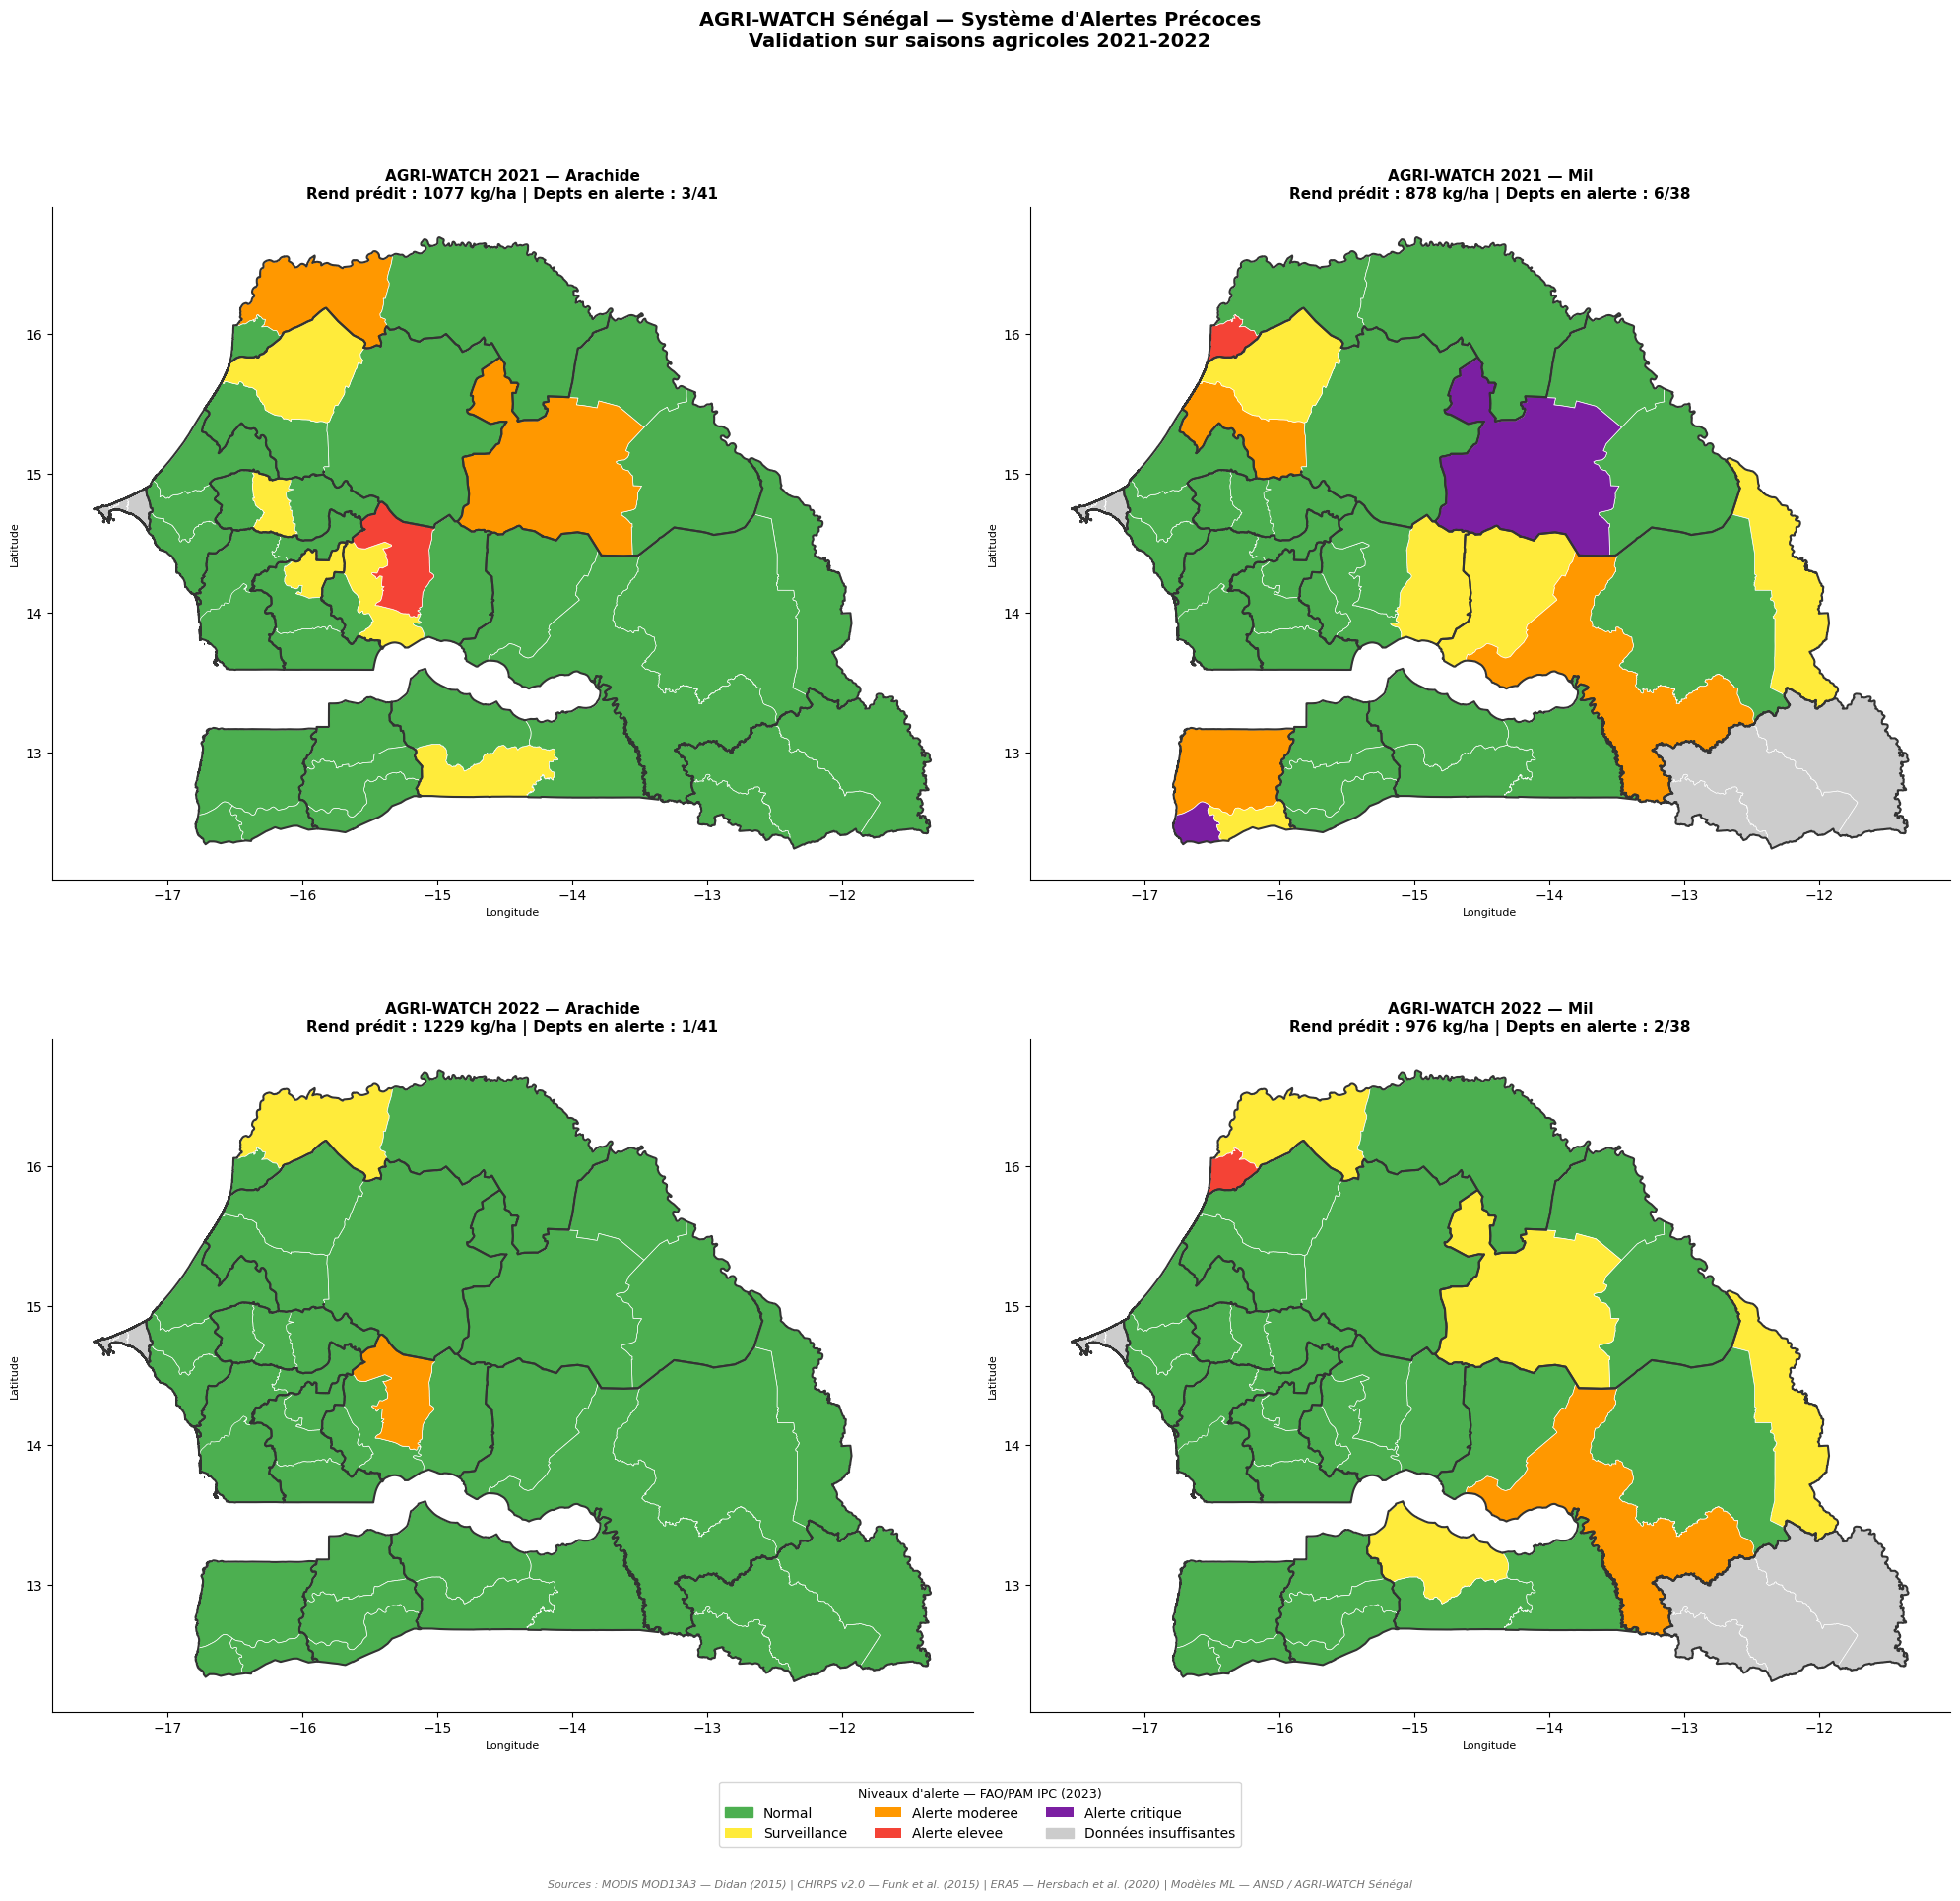


Carte sauvegardée : C:\AGRI-WATCH\outputs\carte_alertes_2021_2022.png
[2026-06-01 01:51:32] [INFO] [agriwatch.systeme_alertes] Carte alertes 2021-2022 sauvegardee.


In [25]:
# ============================================
# Carte alertes 2021-2022
# ============================================
# Visualisation cartographique des niveaux
# d'alerte prédits par AGRI-WATCH
# pour les saisons 2021 et 2022
#
# Sources :
#   FAO/PAM (2023). IPC.
#   FAO/GIEWS ASIS (2017).
# ============================================

print("=" * 65)
print("CARTES ALERTES 2021-2022")
print("=" * 65)

fig, axes = plt.subplots(
    2, 2, figsize=(20, 18)
)

for row_idx, annee in enumerate([2021, 2022]):
    for col_idx, culture in enumerate(
        ["Arachide", "Mil"]
    ):
        ax = axes[row_idx][col_idx]

        df_c = df_alertes_val[
            (df_alertes_val["annee"]   == annee) &
            (df_alertes_val["culture"] == culture)
        ].copy()

        # Exclusion depts urbains
        df_c = df_c[
            ~df_c["departement"].isin(
                ["Dakar", "Guédiawaye",
                 "Pikine", "Rufisque"]
            )
        ]

        # Fusion shapefile
        dept_alerte = departements.merge(
            df_c[[
                "departement", "niveau_alerte",
                "rend_predit", "deficit_pct",
                "code_alerte"
            ]],
            left_on  = COL_NOM_DEPARTEMENT,
            right_on = "departement",
            how      = "left"
        )

        dept_alerte["couleur"] = dept_alerte[
            "niveau_alerte"
        ].map(COULEURS_ALERTE).fillna("#CCCCCC")

        # Tracé carte
        for _, r in dept_alerte.iterrows():
            gpd.GeoDataFrame(
                [r], geometry="geometry"
            ).plot(
                ax        = ax,
                color     = r["couleur"],
                edgecolor = "white",
                linewidth = 0.5
            )

        # Contours régions
        regions.plot(
            ax        = ax,
            color     = "none",
            edgecolor = "#333333",
            linewidth = 1.5
        )

        # Stats
        nb_alerte = (df_c["code_alerte"] >= 2).sum()
        nb_total  = len(df_c)
        rend_moy  = df_c["rend_predit"].mean()

        ax.set_title(
            f"AGRI-WATCH {annee} — {culture}\n"
            f"Rend prédit : {rend_moy:.0f} kg/ha | "
            f"Depts en alerte : {nb_alerte}/{nb_total}",
            fontsize   = 11,
            fontweight = "bold"
        )
        ax.set_xlabel("Longitude", fontsize=8)
        ax.set_ylabel("Latitude",  fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# ── Légende commune ───────────────────────────────────────────
legendes = [
    mpatches.Patch(
        color     = COULEURS_ALERTE[niveau],
        label     = niveau,
        linewidth = 1 if niveau == "Normal" else 0,
        edgecolor = "black"
                    if niveau == "Normal" else None
    )
    for niveau in SEUILS_ALERTE.keys()
]
legendes.append(
    mpatches.Patch(
        color = "#CCCCCC",
        label = "Données insuffisantes"
    )
)

fig.legend(
    handles        = legendes,
    loc            = "lower center",
    ncol           = 3,
    fontsize       = 10,
    frameon        = True,
    title          = "Niveaux d'alerte — FAO/PAM IPC (2023)",
    title_fontsize = 9,
    bbox_to_anchor = (0.5, -0.02)
)

fig.text(
    0.5, -0.04,
    "Sources : MODIS MOD13A3 — Didan (2015) | "
    "CHIRPS v2.0 — Funk et al. (2015) | "
    "ERA5 — Hersbach et al. (2020) | "
    "Modèles ML — ANSD / AGRI-WATCH Sénégal",
    ha      = "center",
    fontsize = 8,
    style   = "italic",
    color   = "#757575"
)

plt.suptitle(
    "AGRI-WATCH Sénégal — Système d'Alertes Précoces\n"
    "Validation sur saisons agricoles 2021-2022",
    fontsize   = 14,
    fontweight = "bold",
    y          = 1.02
)

plt.tight_layout()

output_carte = Path(
    "C:/AGRI-WATCH/outputs/"
    "carte_alertes_2021_2022.png"
)
plt.savefig(
    output_carte,
    dpi         = 150,
    bbox_inches = "tight"
)
plt.show()

print(f"\nCarte sauvegardée : {output_carte}")
logger.info("Carte alertes 2021-2022 sauvegardee.")
print("=" * 65)

In [26]:
# ============================================
# Synthèse Notebook 08
# ============================================

print("=" * 65)
print("SYNTHESE NOTEBOOK 08 — SYSTEME D'ALERTES")
print("=" * 65)

print("""
ARCHITECTURE DU SYSTEME D'ALERTES :

Entree (septembre) :
-> NDVI septembre      (MODIS)
-> Precipitations      (CHIRPS)
-> Variables climatiques (ERA5)
-> SPI + Anomalies     (Notebook 06)

Modeles ML :
-> Random Forest       (Arachide)
-> XGBoost + lags      (Mil)

Sortie :
-> Rendement predit (kg/ha)
-> Deficit vs normale (%)
-> Niveau d'alerte (5 niveaux)
-> Carte nationale de risque
""")

print("SEUILS D'ALERTE :")
print("Source : FAO/PAM IPC (2023)")
print("-" * 40)
for niveau, (bas, haut) in SEUILS_ALERTE.items():
    if haut == float("inf"):
        seuil = "> 0%"
    elif bas == float("-inf"):
        seuil = "< -40%"
    else:
        seuil = f"{bas*100:.0f}% a {haut*100:.0f}%"
    print(f"   {niveau:<20} : {seuil}")

print("""
RESULTATS VALIDATION 2021-2022 :

Saison 2021 :
-> Arachide : 3/41 depts en alerte
   Maleme Hodar (elevee)
   Dagana (moderee)
   Ranerou Ferlo (moderee)
-> Mil : 6/38 depts en alerte
   Oussouye (critique)
   Kedougou (critique)
   Saint-Louis (moderee)

Saison 2022 :
-> Arachide : 1/41 dept en alerte
   Maleme Hodar (moderee)
-> Mil : 2/38 depts en alerte
   Saint-Louis (elevee)
   Tambacounda (moderee)

Coherence avec Notebook 06 :
-> Saint-Louis vulnerable confirme
-> SPI 2022 = +1.17 -> moins d'alertes
-> Gradient nord/sud respecte
""")

print("ZONES PRIORITAIRES IDENTIFIEES :")
print("-" * 40)

zones_prioritaires = df_alertes_val[
    df_alertes_val["code_alerte"] >= 2
].groupby("departement").agg(
    nb_alertes = ("code_alerte", "count"),
    alerte_max = ("niveau_alerte", lambda x:
                  x.value_counts().index[0])
).reset_index().sort_values(
    "nb_alertes", ascending=False
)

print(
    f"\n{'Departement':<20} "
    f"{'Nb alertes':>12} "
    f"{'Niveau dominant':>18}"
)
print("-" * 55)
for _, row in zones_prioritaires.iterrows():
    print(
        f"{row['departement']:<20} "
        f"{row['nb_alertes']:>12} "
        f"{row['alerte_max']:>18}"
    )

print("""
VALEUR AJOUTEE D'AGRI-WATCH :

-> Alertes produites en septembre
   soit 6-8 semaines avant la recolte
-> Identification spatiale fine
   au niveau departemental
-> Double information :
   rendement prevu (kg/ha) ET
   niveau d'alerte (5 niveaux)
-> Coherence avec indicateurs
   officiels SPI (OMM) et
   anomalie NDVI (FAO/GIEWS)
-> Modeles explicables via SHAP
""")

print("FICHIERS PRODUITS :")
outputs = ["carte_alertes_2021_2022.png"]
for f in outputs:
    path = Path("C:/AGRI-WATCH/outputs") / f
    if path.exists():
        print(f"   OK : {f}")
    else:
        print(f"   MANQUANT : {f}")

print("\nNotebook 08 termine !")
print("=" * 65)

logger.info("Notebook 08 termine avec succes.")

SYNTHESE NOTEBOOK 08 — SYSTEME D'ALERTES

ARCHITECTURE DU SYSTEME D'ALERTES :

Entree (septembre) :
-> NDVI septembre      (MODIS)
-> Precipitations      (CHIRPS)
-> Variables climatiques (ERA5)
-> SPI + Anomalies     (Notebook 06)

Modeles ML :
-> Random Forest       (Arachide)
-> XGBoost + lags      (Mil)

Sortie :
-> Rendement predit (kg/ha)
-> Deficit vs normale (%)
-> Niveau d'alerte (5 niveaux)
-> Carte nationale de risque

SEUILS D'ALERTE :
Source : FAO/PAM IPC (2023)
----------------------------------------
   Normal               : > 0%
   Surveillance         : -10% a 0%
   Alerte moderee       : -25% a -10%
   Alerte elevee        : -40% a -25%
   Alerte critique      : < -40%

RESULTATS VALIDATION 2021-2022 :

Saison 2021 :
-> Arachide : 3/41 depts en alerte
   Maleme Hodar (elevee)
   Dagana (moderee)
   Ranerou Ferlo (moderee)
-> Mil : 6/38 depts en alerte
   Oussouye (critique)
   Kedougou (critique)
   Saint-Louis (moderee)

Saison 2022 :
-> Arachide : 1/41 dept en aler